# 数据准备

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from datasets import load_from_disk
# 读取音频嵌入数据
embeddings_path = "/content/drive/MyDrive/yambda_500m/embeddings"
embeddings = load_from_disk(embeddings_path)

Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

In [3]:
# 读取用户物品交互数据
multi_event_path = "/content/drive/MyDrive/yambda_500m/multi_event"
multi_event = load_from_disk(multi_event_path)

Loading dataset from disk:   0%|          | 0/29 [00:00<?, ?it/s]

In [4]:
# 读取艺人专辑歌曲关系图
album_item_mapping_path = "/content/drive/MyDrive/yambda_500m/album_item_mapping"
album_item_mapping = load_from_disk(album_item_mapping_path)
artist_item_mapping_path = "/content/drive/MyDrive/yambda_500m/artist_item_mapping"
artist_item_mapping = load_from_disk(artist_item_mapping_path)

In [5]:
import torch

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")

PyTorch 版本: 2.10.0+cu128
CUDA 是否可用: True


In [6]:
# 🔥 开启 TF32 加速模式 (A100 显卡必备)
# 'high' 表示允许使用 TensorFloat32，精度略微下降但速度飞快
torch.set_float32_matmul_precision('high')

# 数据预处理和可视化分析

In [7]:
import pandas as pd
import numpy as np
import torch
import time
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

start_time = time.time()

print("🚀 第一步：极速加载数据到内存...")
# 只提取我们需要的列，避免加载无用数据
cols_to_keep = ['uid', 'item_id', 'timestamp', 'is_organic', 'event_type', 'played_ratio_pct']

# 利用底层的 PyArrow 引擎，瞬间转为 Pandas DataFrame
df = multi_event.select_columns(cols_to_keep).to_pandas()

print("🧹 第二步：正在进行高标准的数据清洗...")
# 瞬间填充空值为 0
df['played_ratio_pct'] = df['played_ratio_pct'].fillna(0.0)

# Pandas 向量化条件过滤，这在底层是 C 语言运行的，只需几秒钟
mask_like = df['event_type'] == 'like'
mask_listen = (df['event_type'] == 'listen') & (df['played_ratio_pct'] >= 50.0)

valid_mask = (mask_like | mask_listen)

total_raw = len(df)
# 应用掩码，保留干净数据
df_clean = df[valid_mask]
total_valid = len(df_clean)

# 修改后：保护长尾物品的单向过滤
print("🧹 正在进行【保留长尾】的高标准清洗...")

# 1. 物品端：极轻度过滤（比如只过滤掉全站只听过 1 次的绝对噪音，保留 >=2 的所有长尾）
min_item_inter = 2
item_counts = df_clean.groupby('item_id').size()
valid_i = item_counts[item_counts >= min_item_inter].index
df_clean = df_clean[df_clean['item_id'].isin(valid_i)]

# 2. 用户端：严格过滤（保证每个用户至少有 5 条记录，才能切分出 训练集/测试集）
min_user_inter = 5
user_counts = df_clean.groupby('uid').size()
valid_u = user_counts[user_counts >= min_user_inter].index
df_clean = df_clean[df_clean['uid'].isin(valid_u)]

print(f"   -> 原始交互总数: {total_raw}")
print(f"   -> 清洗后有效交互数: {total_valid} (剔除了 {total_raw - total_valid} 条无效交互)")

print("⏳ 第三步：提取纯 C 级底层数组并进行全局排序...")
# 直接提取 DataFrame 的 .values (底层就是连续的 NumPy C 数组)
uids = df_clean['uid'].values
item_ids = df_clean['item_id'].values
timestamps = df_clean['timestamp'].values

# 联合排序 (按 uid 排，uid 内部按 timestamp 排)
sort_idx = np.lexsort((timestamps, uids))
sorted_uids = uids[sort_idx]
sorted_items = item_ids[sort_idx]

print("⚡ 第四步：极速切分用户序列...")
# 核心加速魔法：利用 numpy 的 C 级数组切分
change_indices = np.where(sorted_uids[:-1] != sorted_uids[1:])[0] + 1
unique_uids = np.concatenate(([sorted_uids[0]], sorted_uids[change_indices]))
split_items = np.split(sorted_items, change_indices)

print("📦 第五步：正在组装用户序列字典...")
# 组装字典
user_seqs = {
    u.item(): items.tolist()
    for u, items in tqdm(zip(unique_uids, split_items), total=len(unique_uids), desc="组装进度", unit="user")
}

print(f"✅ 序列构建完成！总耗时: {time.time() - start_time:.2f} 秒\n")


🚀 第一步：极速加载数据到内存...
🧹 第二步：正在进行高标准的数据清洗...
🧹 正在进行【保留长尾】的高标准清洗...
   -> 原始交互总数: 480255564
   -> 清洗后有效交互数: 304024436 (剔除了 176231128 条无效交互)
⏳ 第三步：提取纯 C 级底层数组并进行全局排序...
⚡ 第四步：极速切分用户序列...
📦 第五步：正在组装用户序列字典...


组装进度: 100%|██████████| 98929/98929 [00:16<00:00, 5852.06user/s]

✅ 序列构建完成！总耗时: 267.82 秒



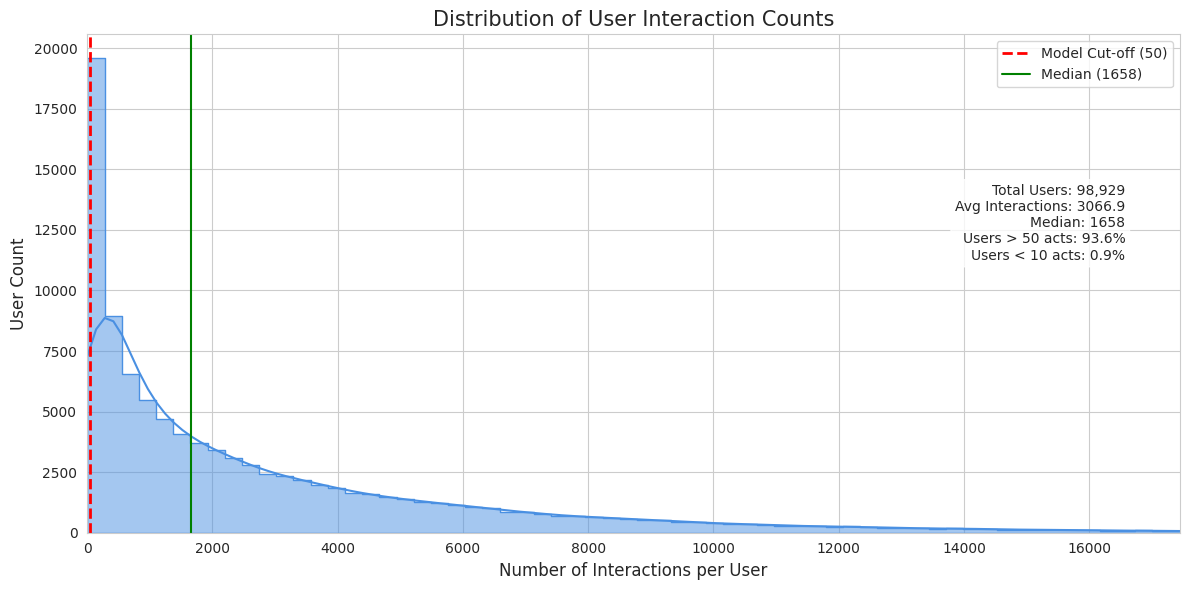

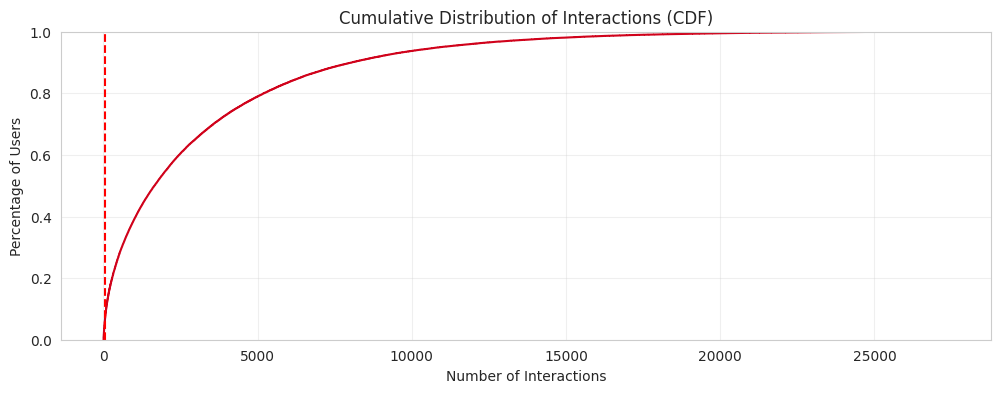

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 统计每个用户的交互序列长度
# 假设你已经运行了构建 user_seqs 的单元格
if 'user_seqs' in locals():
    # 提取所有用户的序列长度
    lengths = [len(seq) for seq in user_seqs.values()]
    lengths = np.array(lengths)

    # 2. 计算关键统计指标
    mean_len = np.mean(lengths)
    median_len = np.median(lengths)
    max_len_val = np.max(lengths)
    p90 = np.percentile(lengths, 90)

    # 超过 50 次和少于 10 次的比例
    over_50 = (lengths > 50).mean() * 100
    under_10 = (lengths < 10).mean() * 100

    # 3. 开始绘图
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    # 绘制直方图 (使用对数坐标以便看清长尾)
    sns.histplot(lengths, bins=100, kde=True, color='#4A90E2', element="step")

    # 添加截断基准线 (50次)
    plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label=f'Model Cut-off (50)')
    plt.axvline(x=median_len, color='green', linestyle='-', linewidth=1.5, label=f'Median ({median_len:.0f})')

    # 修饰图表
    plt.title('Distribution of User Interaction Counts', fontsize=15)
    plt.xlabel('Number of Interactions per User', fontsize=12)
    plt.ylabel('User Count', fontsize=12)

    # 设置 X 轴范围（截取到 P99 左右，防止极个别超级活跃用户拉长坐标轴）
    plt.xlim(0, np.percentile(lengths, 99))

    # 添加信息文本框
    stats_text = (f"Total Users: {len(lengths):,}\n"
                  f"Avg Interactions: {mean_len:.1f}\n"
                  f"Median: {median_len:.0f}\n"
                  f"Users > 50 acts: {over_50:.1f}%\n"
                  f"Users < 10 acts: {under_10:.1f}%")
    plt.text(0.95, 0.7, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4. 辅助观察：累积分布图 (CDF)
    plt.figure(figsize=(12, 4))
    sns.ecdfplot(lengths, color='#D0021B')
    plt.axvline(x=50, color='red', linestyle='--')
    plt.title('Cumulative Distribution of Interactions (CDF)')
    plt.xlabel('Number of Interactions')
    plt.ylabel('Percentage of Users')
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("❌ 请确保先运行了构建 user_seqs 的单元格！")

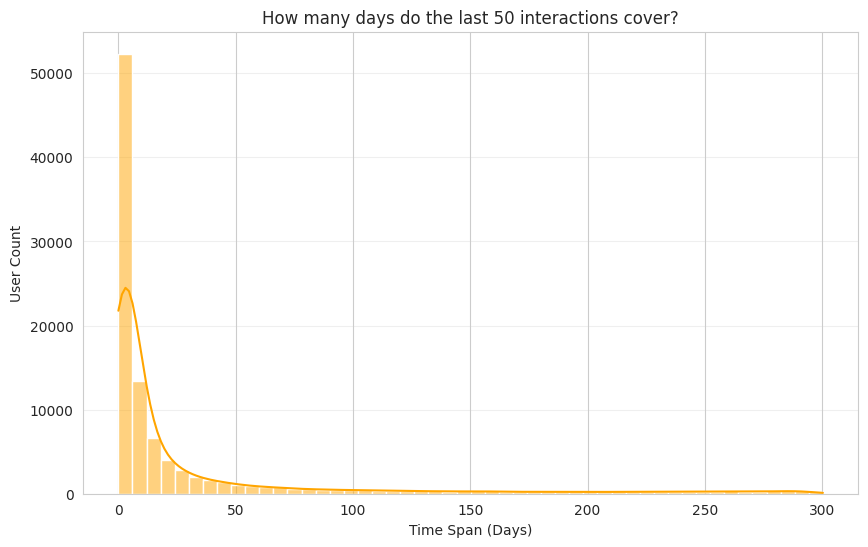

统计用户数: 98929
平均覆盖天数: 28.27 天
中位数: 5.17 天


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 对整个 DataFrame 按照 uid 和时间戳进行排序 (确保取出的是最后 50 次)
# 这一步是所有高效操作的基础
df_sorted = df_clean.sort_values(by=['uid', 'timestamp'])

# 2. 利用 groupby 和 tail(50) 瞬间获取每个用户最近的最多 50 次交互
# 这是 Pandas 的底层 C 实现，比循环快成千上万倍
recent_50 = df_sorted.groupby('uid').tail(50)

# 3. 再次利用聚合函数计算每个用户在这 50 次交互中的最大、最小时间戳以及交互次数
span_df = recent_50.groupby('uid')['timestamp'].agg(
    min_ts='min',
    max_ts='max',
    count='count'
)

# 4. 过滤掉交互次数少于 2 次的用户（对应你原代码的 if len(items) >= 2）
span_df = span_df[span_df['count'] >= 2].copy()

# 5. 计算时间跨度（天）
# 假设 timestamp 是以秒为单位的 Unix 时间戳
span_df['span_days'] = (span_df['max_ts'] - span_df['min_ts']) / (24 * 3600)
time_spans = span_df['span_days'].values

# 6. 绘图
plt.figure(figsize=(10, 6))
sns.histplot(time_spans, bins=50, kde=True, color='orange')
plt.title('How many days do the last 50 interactions cover?')
plt.xlabel('Time Span (Days)')
plt.ylabel('User Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 打印一下统计结果辅助分析
print(f"统计用户数: {len(time_spans)}")
print(f"平均覆盖天数: {time_spans.mean():.2f} 天")
print(f"中位数: {pd.Series(time_spans).median():.2f} 天")

In [10]:
# ==========================================
# ✂️ 划分数据集与构建 PyTorch Dataset
# ==========================================
train_seqs, val_seqs, test_seqs = {}, {}, {}

for uid, seq in tqdm(user_seqs.items(), desc="划分数据集", unit="user"):
    if len(seq) < 3:
        continue
    train_seqs[uid] = seq[:-2]
    val_seqs[uid] = seq[:-1]
    test_seqs[uid] = seq

print(f"\n✅ 有效训练用户数: {len(train_seqs)}")

class SequenceDataset(Dataset):
    def __init__(self, user_seqs, max_len=50):
        self.uids = list(user_seqs.keys())
        self.seqs = [user_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        seq = seq[-self.max_len-1:]

        pad_len = self.max_len + 1 - len(seq)
        seq = [0] * pad_len + seq

        x = torch.tensor(seq[:-1], dtype=torch.long)
        y = torch.tensor(seq[1:], dtype=torch.long)
        return x, y

MAX_SEQ_LEN = 50
train_dataset = SequenceDataset(train_seqs, max_len=MAX_SEQ_LEN)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

划分数据集: 100%|██████████| 98929/98929 [00:11<00:00, 8942.79user/s]



✅ 有效训练用户数: 98929


In [11]:
print("🚀 正在构建全局对齐的声学特征矩阵...")
start_emb_time = time.time()

# 1. 将 embeddings 数据集极速转为 Pandas DataFrame
df_emb = embeddings.select_columns(['item_id', 'embed']).to_pandas()

# 2. 找到全局最大的 item_id，以确定我们需要多大的词表 (Vocabulary Size)
# 确保矩阵的行数足够容纳所有的 item_id
max_item_id = max(df_clean['item_id'].max(), df_emb['item_id'].max())
feature_dim = len(df_emb.iloc[0]['embed'])

# 3. 初始化全 0 矩阵 (行数为 max_item_id + 1，第 0 行自然被保留为 0 用于 Padding)
track_vectors = np.zeros((max_item_id + 1, feature_dim), dtype=np.float32)

# 4. 利用 NumPy 的高级索引 (Advanced Indexing) 瞬间将特征填入对应行
# df_emb['item_id'].values 作为行索引，精准对齐
track_vectors[df_emb['item_id'].values] = np.vstack(df_emb['embed'].values)

num_tracks = max_item_id # 这将是我们传入模型的物品总量

print(f"✅ 特征矩阵构建完成！")
print(f"   -> 矩阵形状: {track_vectors.shape} (行数=词表大小+1, 列数=特征维度)")
print(f"   -> 总耗时: {time.time() - start_emb_time:.2f} 秒\n")

🚀 正在构建全局对齐的声学特征矩阵...
✅ 特征矩阵构建完成！
   -> 矩阵形状: (9390624, 128) (行数=词表大小+1, 列数=特征维度)
   -> 总耗时: 102.94 秒



# 定义验证集与验证函数

In [12]:
# ==========================================
# 0. 补全缺失的验证集定义 (解决 NameError)
# ==========================================
from torch.utils.data import Dataset, DataLoader

class ValSequenceDataset(Dataset):
    def __init__(self, val_seqs, max_len=50):
        self.uids = list(val_seqs.keys())
        self.seqs = [val_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        # 验证集：用倒数第二首 (target) 之前的序列 (hist) 进行预测
        target = seq[-1]
        hist = seq[:-1]

        hist = hist[-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist

        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

# 确保 MAX_SEQ_LEN 已经定义（之前我们设为 50）
if 'MAX_SEQ_LEN' not in locals():
    MAX_SEQ_LEN = 50

# 创建验证集加载器
val_dataset = ValSequenceDataset(val_seqs, max_len=MAX_SEQ_LEN)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

print("✅ val_loader 已成功定义！现在可以重新运行训练单元格了。")

✅ val_loader 已成功定义！现在可以重新运行训练单元格了。


In [13]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score # 🌟 补上这个关键导入

@torch.no_grad()
def evaluate_auc_pro(model, val_loader, num_items, device):
    model.eval()
    all_targets, all_preds = [], []

    for x, target in val_loader:
        x, target = x.to(device), target.to(device)

        # 强制使用 float32 避免半精度带来的数值不稳定
        fused_out = model(x).float()
        last_step_state = fused_out[:, -1, :]

        # 计算正样本得分 (L2 归一化后的点积)
        pos_embs = model.get_item_representation(target).float()
        pos_scores = (last_step_state * pos_embs).sum(dim=-1, keepdim=True)

        # 负样本随机采样 99 个
        negatives = torch.randint(1, num_items + 1, (x.size(0), 99), device=device)
        neg_embs = model.get_item_representation(negatives).float()
        neg_scores = (last_step_state.unsqueeze(1) * neg_embs).sum(dim=-1)

        # 转换为 numpy 并清除 NaN (双重保险)
        scores = torch.cat([pos_scores, neg_scores], dim=1).view(-1).cpu().numpy()
        scores = np.nan_to_num(scores, nan=0.0)

        all_preds.append(scores)
        all_targets.append(torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)], dim=1).view(-1).cpu().numpy())

    # 计算全局 AUC
    y_true = np.concatenate(all_targets)
    y_score = np.concatenate(all_preds)

    return roc_auc_score(y_true, y_score)

print("✅ 所有库已导入，验证函数 evaluate_auc_pro 已准备就绪！")

✅ 所有库已导入，验证函数 evaluate_auc_pro 已准备就绪！


# 结合音频嵌入的双流架构

## 模型定义

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SharedGatedFusion(nn.Module):
    """
    共享门控融合头：
    - sequence 侧：融合上下文化后的 ID / acoustic 表示
    - item 侧：融合静态 ID / acoustic 表示
    两侧共享同一组 gate/proj 参数，保证打分发生在同一表示空间。
    """
    def __init__(self, hidden_dim, dropout=0.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gate = nn.Linear(hidden_dim * 2, 2)
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def compute_gate(self, x_id, x_feat):
        concat = torch.cat([x_id, x_feat], dim=-1)           # [..., 2H]
        gate = torch.softmax(self.gate(concat), dim=-1)      # [..., 2]
        return gate

    def forward(self, x_id, x_feat, return_gate=False):
        gate = self.compute_gate(x_id, x_feat)
        fused = gate[..., 0:1] * x_id + gate[..., 1:2] * x_feat
        fused = torch.relu(self.proj(self.dropout(fused)))
        fused = F.normalize(fused, p=2, dim=-1, eps=1e-8)
        if return_gate:
            return fused, gate
        return fused


class FDSA_Final(nn.Module):
    def __init__(
        self,
        num_items,
        item_dim=64,
        feature_dim=128,
        max_seq_len=50,
        pretrained_features=None,
        num_heads=4,
        num_layers=2,
        dropout=0.2
    ):
        super(FDSA_Final, self).__init__()
        self.max_seq_len = max_seq_len
        self.item_dim = item_dim

        # 1. ID 与音频 Embedding (0 设为 Padding)
        self.item_emb = nn.Embedding(num_items + 1, item_dim, padding_idx=0)
        self.feature_emb = nn.Embedding(num_items + 1, feature_dim, padding_idx=0)

        if pretrained_features is not None:
            feat_weight = torch.tensor(pretrained_features, dtype=torch.float32)
            if feat_weight.size(0) == num_items:
                # 若外部特征不含 padding 行，则自动前补零
                feat_weight = torch.cat(
                    [torch.zeros(1, feat_weight.size(1), dtype=feat_weight.dtype), feat_weight],
                    dim=0
                )
            if feat_weight.size(0) != num_items + 1:
                raise ValueError(
                    f"pretrained_features 行数应为 {num_items + 1}（含 padding）或 {num_items}（不含 padding），"
                    f"当前为 {feat_weight.size(0)}"
                )
            self.feature_emb.weight.data.copy_(feat_weight)
            self.feature_emb.weight.requires_grad = True

        self.feature_proj = nn.Linear(feature_dim, item_dim)
        self.pos_emb = nn.Embedding(max_seq_len, item_dim)

        # 2. 双流 Transformer
        id_encoder_layer = nn.TransformerEncoderLayer(
            d_model=item_dim, nhead=num_heads,
            dim_feedforward=item_dim * 4, dropout=dropout, batch_first=True
        )
        feat_encoder_layer = nn.TransformerEncoderLayer(
            d_model=item_dim, nhead=num_heads,
            dim_feedforward=item_dim * 4, dropout=dropout, batch_first=True
        )
        self.id_encoder = nn.TransformerEncoder(id_encoder_layer, num_layers=num_layers)
        self.feature_encoder = nn.TransformerEncoder(feat_encoder_layer, num_layers=num_layers)

        # 3. 共享融合头：sequence 侧和 item 侧共用
        self.fusion = SharedGatedFusion(item_dim, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def _build_masks(self, seqs):
        device = seqs.device
        batch_size, seq_len = seqs.size()
        padding_mask = (seqs == 0)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len, device=device).bool()
        positions = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)
        return padding_mask, causal_mask, positions

    def encode_modalities(self, seqs):
        """
        返回上下文化后的两路表示：
        z_id, z_feat: [B, L, D]
        """
        batch_size, seq_len = seqs.size()
        padding_mask, causal_mask, positions = self._build_masks(seqs)
        pos_embeddings = self.pos_emb(positions)

        # 流 1: ID
        id_embs = self.item_emb(seqs) + pos_embeddings
        z_id = self.id_encoder(
            self.dropout(id_embs),
            mask=causal_mask,
            src_key_padding_mask=padding_mask
        )

        # 流 2: Acoustic Feature
        feat_embs = self.feature_proj(self.feature_emb(seqs)) + pos_embeddings
        z_feat = self.feature_encoder(
            self.dropout(feat_embs),
            mask=causal_mask,
            src_key_padding_mask=padding_mask
        )

        return z_id, z_feat

    def forward(self, seqs, return_gate=False):
        """
        序列编码：输出归一化后的隐状态 [B, L, D]
        """
        z_id, z_feat = self.encode_modalities(seqs)
        if return_gate:
            fused_out, gate = self.fusion(z_id, z_feat, return_gate=True)
            return fused_out, gate
        return self.fusion(z_id, z_feat, return_gate=False)

    def get_item_modalities(self, item_ids):
        e_id = self.item_emb(item_ids)
        e_feat = self.feature_proj(self.feature_emb(item_ids))
        return e_id, e_feat

    def get_item_representation(self, item_ids, return_gate=False):
        """
        物品编码：输出归一化后的物品表征 [..., D]
        注意：这里也走同一个共享融合头，而不是直接 e_id + e_feat
        """
        e_id, e_feat = self.get_item_modalities(item_ids)
        if return_gate:
            rep, gate = self.fusion(e_id, e_feat, return_gate=True)
            return rep, gate
        return self.fusion(e_id, e_feat, return_gate=False)

    def get_last_step_gate(self, seqs):
        """
        返回最后一步的 gate 权重，便于可视化：
        gates: [B, 2]，两列分别是 [ID_gate, Acoustic_gate]
        """
        _, gate = self.forward(seqs, return_gate=True)
        return gate[:, -1, :]

# 重新初始化模型
model = FDSA_Final(
    num_items=num_tracks,
    pretrained_features=track_vectors,
    item_dim=64,
    num_heads=4,
    num_layers=2
).to(device)

print("✅ FDSA_Final（共享门控融合头版）模型已定义并初始化完毕！")

✅ FDSA_Final（共享门控融合头版）模型已定义并初始化完毕！


## 模型训练

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
import time

# ==========================================
# 1. 确保基础变量存在
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 如果 num_tracks 没定义，尝试从特征矩阵获取
if 'num_tracks' not in locals():
    num_tracks = track_vectors.shape[0]

# ==========================================
# 3. 稳健训练循环 (带梯度裁剪)
# ==========================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scaler = GradScaler('cuda')

# 🌟 核心参数
temperature = 0.2  # 配合 L2 归一化
best_auc = 0.5
patience = 5
patience_counter = 0

print("\n🔥 启动增强版训练 (L2 Normalization + Optimized Temp)...")



for epoch in range(100):
    model.train()
    total_loss = 0.0
    start_t = time.time()

    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with autocast(device_type='cuda', dtype=torch.float16):
            # 1. 前向传播：获取归一化的隐状态 [B, L, D]
            h_seq = model(x)

            # 2. 展平并提取有效样本 (非 Padding)
            h_flat = h_seq.view(-1, h_seq.size(-1))
            y_flat = y.view(-1)
            valid_mask = (y_flat != 0)

            h_valid = h_flat[valid_mask]
            y_valid = y_flat[valid_mask]

            # 3. 获取目标物品归一化表征
            e_target = model.get_item_representation(y_valid)

            # 4. 计算余弦相似度矩阵并应用温度系数
            logits = torch.matmul(h_valid, e_target.t()) / temperature

            # 5. 构造标签 (对角线为正样本)
            labels = torch.arange(h_valid.size(0), device=device)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        # 🌟 增加梯度裁剪，防止梯度爆炸
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

        if (i+1) % 100 == 0:
            print(f"   Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # ==========================================
    # 验证阶段
    # ==========================================
    # 确保 evaluate_auc_pro 已在之前的单元格定义
    try:
        val_auc = evaluate_auc_pro(model, val_loader, num_tracks, device)
        print(f"✅ Epoch {epoch+1} | Avg Loss: {total_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f} | Time: {time.time()-start_t:.1f}s")

        if val_auc > best_auc :
            best_auc = val_auc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model_shared_gated_pro.pth')
            print(f"🌟 新纪录！模型已保存至 best_model_shared_gated_pro.pth")
        else:
            patience_counter += 1
            print(f"📉 AUC 未提升 | 早停计数: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("🛑 停止训练")
                break
    except NameError as e:
        print(f"❌ 验证失败：{e}。请确保已运行定义 evaluate_auc_pro 的单元格。")
        break

    print("-" * 50)


🔥 启动增强版训练 (L2 Normalization + Optimized Temp)...
   Batch 100/387 | Loss: 8.2198
   Batch 200/387 | Loss: 8.1820
   Batch 300/387 | Loss: 8.2035
✅ Epoch 1 | Avg Loss: 8.2219 | Val AUC: 0.8711 | Time: 81.2s
🌟 新纪录！模型已保存至 best_model_shared_gated_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 8.0386
   Batch 200/387 | Loss: 8.0121
   Batch 300/387 | Loss: 7.9514
✅ Epoch 2 | Avg Loss: 7.9878 | Val AUC: 0.8862 | Time: 79.4s
🌟 新纪录！模型已保存至 best_model_shared_gated_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.9170
   Batch 200/387 | Loss: 7.9120
   Batch 300/387 | Loss: 7.9158
✅ Epoch 3 | Avg Loss: 7.8752 | Val AUC: 0.8963 | Time: 78.8s
🌟 新纪录！模型已保存至 best_model_shared_gated_pro.pth
--------------------------------------------------
   Batch 100/387 | Loss: 7.7624
   Batch 200/387 | Loss: 7.7696
   Batch 300/387 | Loss: 7.7586
✅ Epoch 4 | Avg Loss: 7.7997 | Val AUC: 0.9036 | Time: 85.7s
🌟 新纪录！模型已保存至 best_model_shared_gat

In [17]:
# 上传至hugging face
from huggingface_hub import upload_file
from huggingface_hub import login

login()

upload_file(
    path_or_fileobj="best_model_shared_gated_pro.pth",
    path_in_repo="best_model_shared_gated_pro.pth",
    repo_id="Pcpp/music-transformer",
    repo_type="model"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...odel_shared_gated_pro.pth:   0%|          |  557kB / 7.21GB            

CommitInfo(commit_url='https://huggingface.co/Pcpp/music-transformer/commit/1e97123d04e2944b3998d3a52d0dfca8116d1bad', commit_message='Upload best_model_shared_gated_pro.pth with huggingface_hub', commit_description='', oid='1e97123d04e2944b3998d3a52d0dfca8116d1bad', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Pcpp/music-transformer', endpoint='https://huggingface.co', repo_type='model', repo_id='Pcpp/music-transformer'), pr_revision=None, pr_num=None)

## 模型评估

In [18]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import itertools

print("📊 准备 FDSA 序列模型专属的多维度评估数据...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 0. 加载巅峰模型权重
# ==========================================
try:
    model.load_state_dict(
        torch.load('best_model_shared_gated_pro.pth', map_location=device)
    )
    print("✅ 已成功加载验证集 AUC 最高的巅峰模型权重！")

except FileNotFoundError:
    print("❌ 未找到 best_model_shared_gated_pro.pth 权重文件")

model.eval()

# ==========================================
# 1. 极速计算全局热度与音乐特定属性 (基于干净的训练集序列)
# ==========================================
print("📈 正在极速计算音乐专属评价属性...")
num_tracks = track_vectors.shape[0]

# 🌟 核心优化：瞬间展平所有用户的训练序列，避免 Python 双重 for 循环
flat_items = list(itertools.chain.from_iterable(train_seqs.values()))

# 将展平的列表一次性送入 GPU，利用底层的 C/CUDA 极速计算频次
flat_items_tensor = torch.tensor(flat_items, dtype=torch.long, device=device)
track_counts = torch.bincount(flat_items_tensor, minlength=num_tracks + 1)

# 排除 padding (0) 的统计干扰
track_counts[0] = 0

# A. 提取热门歌曲作为困难负样本池 (取 min 防止越界)
POOL_SIZE = min(50000, num_tracks)
top_popular_tracks = torch.topk(track_counts, POOL_SIZE).indices

# B. 计算新颖度概率 (Novelty)
track_probs = (track_counts / track_counts.sum())
track_novelty = -torch.log2(track_probs + 1e-9)

# C. 计算头部物品掩码 (定义 Top 5000 为头部金曲)
head_indices = torch.topk(track_counts, min(5000, num_tracks)).indices
is_head_item = torch.zeros(num_tracks + 1, dtype=torch.bool, device=device)
is_head_item[head_indices] = True

# ==========================================
# 2. 构建测试集 DataLoader (Leave-One-Out)
# ==========================================
class TestSequenceDataset(Dataset):
    def __init__(self, test_seqs, max_len=50):
        self.uids = list(test_seqs.keys())
        self.seqs = [test_seqs[uid] for uid in self.uids]
        self.max_len = max_len

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        # 测试集：用除了最后一首之外的所有历史去预测最后一首
        target = seq[-1]
        hist = seq[:-1][-self.max_len:]
        pad_len = self.max_len - len(hist)
        hist = [0] * pad_len + hist
        return torch.tensor(hist, dtype=torch.long), torch.tensor(target, dtype=torch.long)

test_dataset = TestSequenceDataset(test_seqs, max_len=MAX_SEQ_LEN)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# ==========================================
# 🚀 3. 开始 1 vs 999 评估循环
# ==========================================
print(f"🚀 开始硬核评估 (测试序列数: {len(test_dataset)}，候选集: 1正+999负)...")

K_LIST = [10, 100]
results = {k: {'Recall': [], 'NDCG': [], 'Novelty': [], 'Diversity': [], 'LongTail': []} for k in K_LIST}
global_coverage_set = {k: set() for k in K_LIST}

# 提取纯粹的声学特征用于多样性计算
raw_acoustic_features = torch.tensor(track_vectors, device=device, dtype=torch.float32)

with torch.no_grad():
    for x, target in tqdm(test_loader, desc="评测进度"):
        x, target = x.to(device), target.to(device)
        batch_size = x.size(0)

        # --- 核心修改：动态计算用户意图表征 ---
        # 获取模型最后一步的归一化隐状态 [B, 64]
        fused_out = model(x)
        batch_user_vecs = fused_out[:, -1, :].unsqueeze(1) # [B, 1, 64]

        # --- 准备候选集 [Batch, 1000] ---
        pos_tids = target.unsqueeze(1) # [B, 1]
        neg_idx = torch.randint(0, POOL_SIZE, (batch_size, 999), device=device)
        neg_candidates = top_popular_tracks[neg_idx] # [B, 999]

        candidates_tids = torch.cat([pos_tids, neg_candidates], dim=1) # [B, 1000]

        # 动态计算候选物品的综合表征 (ID + Feature) [B, 1000, 64]
        batch_cand_vecs = model.get_item_representation(candidates_tids)

        # --- 计算分数与排序 ---
        scores = (batch_user_vecs * batch_cand_vecs).sum(dim=-1) # [B, 1000]
        _, top_indices = torch.topk(scores, k=max(K_LIST), dim=1)

        # 提取真实的推荐 Track ID [B, max_K]
        rec_tids = candidates_tids.gather(1, top_indices)

        # --- 计算多维度指标 ---
        for k in K_LIST:
            tk_indices = top_indices[:, :k]
            tk_tids = rec_tids[:, :k]

            # 1. Recall / Hit Rate
            hits = (tk_indices == 0).float()
            results[k]['Recall'].extend(hits.sum(dim=1).cpu().numpy())

            # 2. NDCG
            for row_hits in hits:
                if row_hits.sum() > 0:
                    rank = (row_hits == 1).nonzero(as_tuple=True)[0].item()
                    results[k]['NDCG'].append(1.0 / np.log2(rank + 2))
                else:
                    results[k]['NDCG'].append(0.0)

            # 3. Novelty (新颖度)
            nov = track_novelty[tk_tids].mean(dim=1).cpu().numpy()
            results[k]['Novelty'].extend(nov)

            # 4. Long-Tail Rate (长尾挖掘率)
            tail_rate = (~is_head_item[tk_tids]).float().mean(dim=1).cpu().numpy()
            results[k]['LongTail'].extend(tail_rate)

            # 5. Acoustic Diversity (声学多样性) - 使用原始 128 维音频特征计算
            rec_embs = raw_acoustic_features[tk_tids]
            norm_embs = F.normalize(rec_embs, p=2, dim=-1)
            sim_matrix = torch.bmm(norm_embs, norm_embs.transpose(1, 2))
            # 屏蔽对角线 (自己跟自己的相似度 1.0)
            mask = ~torch.eye(k, dtype=torch.bool, device=device).unsqueeze(0).expand(batch_size, k, k)
            mean_sim = sim_matrix[mask].reshape(batch_size, k, k-1).mean(dim=(1,2))
            diversity = (1.0 - mean_sim).cpu().numpy()
            results[k]['Diversity'].extend(diversity)

            # 6. Coverage (覆盖率)
            unique_tids_in_batch = set(tk_tids.reshape(-1).cpu().numpy())
            global_coverage_set[k].update(unique_tids_in_batch)

# ==========================================
# 📊 4. 输出顶会级学术报告
# ==========================================
print("\n" + "="*55)
print("🏆 FDSA 序列双流模型：全景学术评估报告 (1 vs 999)")
print("="*55)

for k in K_LIST:
    print(f"🎯 【Top-{k} 评估指标】:")
    print(f"   📈 精准度类 (Accuracy):")
    print(f"      - Recall@{k} / HR@{k} : {np.mean(results[k]['Recall']):.4f}")
    print(f"      - NDCG@{k}           : {np.mean(results[k]['NDCG']):.4f}")

    print(f"   🎵 音乐特化类 (Beyond-Accuracy):")
    cov_ratio = len(global_coverage_set[k]) / POOL_SIZE
    print(f"      - Coverage@{k} (系统覆盖率): {cov_ratio:.4f} ({len(global_coverage_set[k])} 首)")
    print(f"      - Novelty@{k}  (平均新颖度): {np.mean(results[k]['Novelty']):.4f} bit")
    print(f"      - Diversity@{k}(声学多样性): {np.mean(results[k]['Diversity']):.4f} (越大越多元)")
    print(f"      - LongTail@{k} (长尾挖掘率): {np.mean(results[k]['LongTail']):.4f} (非爆款占比)")
    print("-" * 55)

📊 准备 FDSA 序列模型专属的多维度评估数据...
✅ 已成功加载验证集 AUC 最高的巅峰模型权重！
📈 正在极速计算音乐专属评价属性...
🚀 开始硬核评估 (测试序列数: 98929，候选集: 1正+999负)...


评测进度: 100%|██████████| 194/194 [00:37<00:00,  5.23it/s]


🏆 FDSA 序列双流模型：全景学术评估报告 (1 vs 999)
🎯 【Top-10 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@10 / HR@10 : 0.4548
      - NDCG@10           : 0.3182
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@10 (系统覆盖率): 1.2274 (61370 首)
      - Novelty@10  (平均新颖度): 16.4880 bit
      - Diversity@10(声学多样性): 0.5375 (越大越多元)
      - LongTail@10 (长尾挖掘率): 0.8353 (非爆款占比)
-------------------------------------------------------
🎯 【Top-100 评估指标】:
   📈 精准度类 (Accuracy):
      - Recall@100 / HR@100 : 0.8028
      - NDCG@100           : 0.3888
   🎵 音乐特化类 (Beyond-Accuracy):
      - Coverage@100 (系统覆盖率): 1.3327 (66634 首)
      - Novelty@100  (平均新颖度): 16.5611 bit
      - Diversity@100(声学多样性): 0.7056 (越大越多元)
      - LongTail@100 (长尾挖掘率): 0.8635 (非爆款占比)
-------------------------------------------------------


In [19]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

## gate 权重可视化

下面补充双流共享门控融合头的可解释性分析。  
这里的 gate 为两维权重：

- `gate[..., 0]`：ID 分支权重
- `gate[..., 1]`：Acoustic 分支权重

我们从三个角度可视化：

1. **序列最后一步 gate 分布**：看用户当前意图更依赖 ID 还是音频。  
2. **不同流行度分组的 item gate**：看长尾歌曲是否更依赖音频嵌入。  
3. **gate 散点图**：观察 ID / Acoustic 权重的竞争关系。

🎛️ 开始提取 gate 权重用于可视化...


提取 sequence gate: 100%|██████████| 194/194 [00:04<00:00, 47.57it/s]


            ID Gate  Acoustic Gate
count  92565.000000   92565.000000
mean       0.003363       0.996637
std        0.001848       0.001863
min        0.000136       0.941107
25%        0.002180       0.995843
50%        0.003018       0.996982
75%        0.004156       0.997820
max        0.058893       0.999864


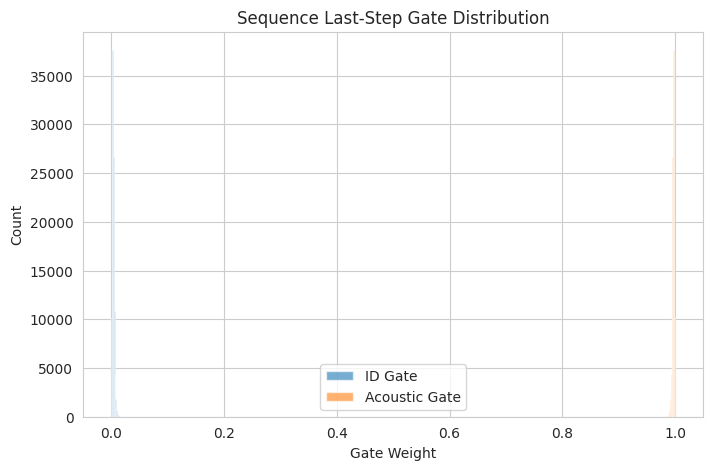

/tmp/ipykernel_8700/2755755964.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_mean = item_gate_df.groupby("pop_bucket")[["ID Gate", "Acoustic Gate"]].mean()


,ID Gate,Acoustic Gate
pop_bucket,,
Q1 Tail,0.076798,0.923202
Q2,0.078088,0.921912
Q3,0.082550,0.917450
Q4 Head,0.089087,0.910913


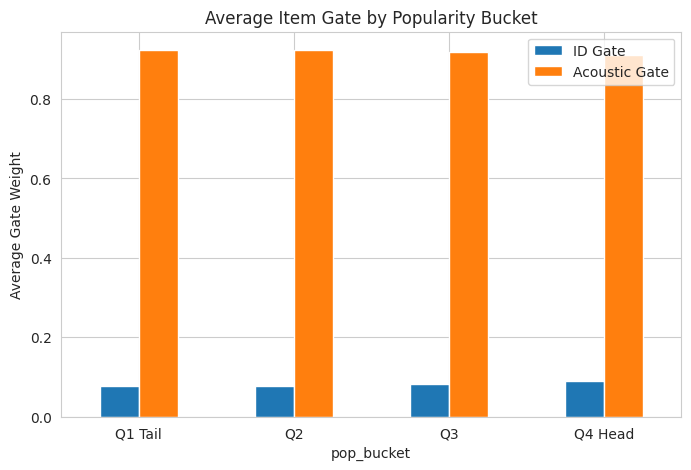

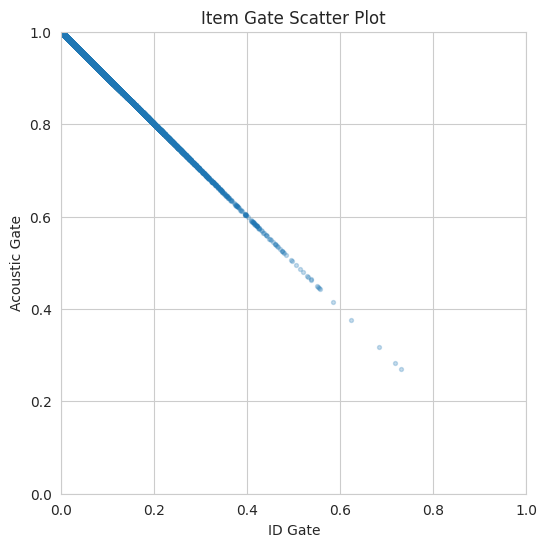

✅ gate 权重可视化完成！


In [20]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

print("🎛️ 开始提取 gate 权重用于可视化...")

# ----------------------------------------------------------
# 1. 序列最后一步 gate 分布
# ----------------------------------------------------------
seq_gate_list = []

with torch.no_grad():
    for x, target in tqdm(test_loader, desc="提取 sequence gate"):
        x = x.to(device)
        last_gate = model.get_last_step_gate(x)   # [B, 2]
        seq_gate_list.append(last_gate.cpu())

seq_gates = torch.cat(seq_gate_list, dim=0).numpy()
seq_gate_df = pd.DataFrame({
    "ID Gate": seq_gates[:, 0],
    "Acoustic Gate": seq_gates[:, 1]
})

print(seq_gate_df.describe())

plt.figure(figsize=(8, 5))
plt.hist(seq_gate_df["ID Gate"], bins=40, alpha=0.6, label="ID Gate")
plt.hist(seq_gate_df["Acoustic Gate"], bins=40, alpha=0.6, label="Acoustic Gate")
plt.xlabel("Gate Weight")
plt.ylabel("Count")
plt.title("Sequence Last-Step Gate Distribution")
plt.legend()
plt.show()

# ----------------------------------------------------------
# 2. item 侧 gate：按流行度分桶
# ----------------------------------------------------------
if 'track_counts' not in locals():
    raise RuntimeError("请先运行双流评估单元，确保 track_counts 已经计算。")

valid_item_ids = torch.nonzero(track_counts > 0).squeeze(1)
valid_item_ids = valid_item_ids[valid_item_ids != 0]

# 为了控制可视化规模，最多抽样 20000 个 item
max_items_for_gate_vis = 20000
if valid_item_ids.numel() > max_items_for_gate_vis:
    perm = torch.randperm(valid_item_ids.numel(), device=valid_item_ids.device)[:max_items_for_gate_vis]
    sampled_item_ids = valid_item_ids[perm]
else:
    sampled_item_ids = valid_item_ids

with torch.no_grad():
    _, item_gates = model.get_item_representation(sampled_item_ids.to(device), return_gate=True)

item_gate_df = pd.DataFrame({
    "item_id": sampled_item_ids.cpu().numpy(),
    "count": track_counts[sampled_item_ids].cpu().numpy(),
    "ID Gate": item_gates[:, 0].detach().cpu().numpy(),
    "Acoustic Gate": item_gates[:, 1].detach().cpu().numpy(),
})

# 用流行度分位数分桶
item_gate_df["pop_bucket"] = pd.qcut(
    item_gate_df["count"].rank(method="first"),
    q=4,
    labels=["Q1 Tail", "Q2", "Q3", "Q4 Head"]
)

bucket_mean = item_gate_df.groupby("pop_bucket")[["ID Gate", "Acoustic Gate"]].mean()
display(bucket_mean)

bucket_mean.plot(kind="bar", figsize=(8, 5))
plt.title("Average Item Gate by Popularity Bucket")
plt.ylabel("Average Gate Weight")
plt.xticks(rotation=0)
plt.show()

# ----------------------------------------------------------
# 3. gate 散点图
# ----------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(
    item_gate_df["ID Gate"],
    item_gate_df["Acoustic Gate"],
    s=8,
    alpha=0.25
)
plt.xlabel("ID Gate")
plt.ylabel("Acoustic Gate")
plt.title("Item Gate Scatter Plot")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

print("✅ gate 权重可视化完成！")